Import all libraries

In [ ]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import EfficientNet_B0_Weights

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import glob


In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define paths to your tiled data
base_path = "/home/student/sky-scan/data/"
original_dir = f"{base_path}/patch"
binary_dir = f"{base_path}/patch-binary"
color_dir = f"{base_path}/patch-texture"
images_, binary_masks_, color_masks_ = [], [], []


Generate tiles for binary and colour images

In [ ]:
def get_all_char_before_dot(s):
    dot_index = s.find('.')
    if dot_index > 0:
        return s[:dot_index]
    else:
        return None  # Return None if there's no character before the dot

def generate_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image
    image = Image.open(image_path)
    image_width, image_height = image.size

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to the bounding box to create the tile
            tile = image.crop(bbox)

            # Save the tile to the output folder
            image_file_name=os.path.basename(image_path)
            image_idx = get_all_char_before_dot(image_file_name)
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png") #image_id_x_y.png

    print(f"✅ Tiles from {image_file_name} are generated successfully.")

def generate_binary_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image in grayscale mode (black & white)
    image = Image.open(image_path).convert("L")  # "L" mode ensures grayscale (0-255)
    image_width, image_height = image.size

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to create the tile
            tile = image.crop(bbox)

            # Convert to binary (0 or 255) to ensure black and white format
            tile = tile.point(lambda p: 255 if p > 127 else 0, mode="1")  # Thresholding

            # Save the tile to the output folder
            image_file_name = os.path.basename(image_path)
            image_idx = image_file_name.split('.')[0]  # Get filename without extension
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png", format="PNG")  # Save as binary PNG

    print(f"✅ Binary tiles from {image_file_name} are generated successfully.")

# Generate tiles for original images
os.makedirs(f'{base_path}/patch', exist_ok=True)

for i in range(1,13): #12 images
    generate_tiles(f'{base_path}/Tiles/{i}.jpg', 256, 256, 128, f'{base_path}/patch')

print("Original images are generated successfully.")

# Generate tiles for binary mask images
os.makedirs(f'{base_path}/patch-binary', exist_ok=True)

for i in range(1,13): #12 images
    generate_binary_tiles(f'{base_path}/mask/{i}.png', 256, 256, 128, f'{base_path}/patch-binary')

print("Binary mask images are generated successfully.")


Load binary and colour images for classification

In [ ]:
def load_tiled_data(original_dir, binary_dir, color_dir):
    filenames = sorted(os.listdir(original_dir))
    for filename in tqdm(filenames, desc="Loading tiles", unit="tile"):
        img_path = os.path.join(original_dir, filename)
        image = Image.open(img_path).convert("RGB")
        images_.append(np.array(image) / 255.0)

        binary_path = os.path.join(binary_dir, filename)
        binary = Image.open(binary_path).convert("L")
        binary_masks_.append(np.array(binary) / 255.0)

        color_path = os.path.join(color_dir, filename)
        color = Image.open(color_path).convert("RGB")
        color_masks_.append(np.array(color) / 255.0)

images ,binary_masks,color_masks=  np.array(images_), np.array(binary_masks_), np.array(color_masks_)

load_tiled_data(original_dir, binary_dir, color_dir)

helper function to extract label from tiles version of the image for deep leanring

In [ ]:
def get_largest_contour_square(image_input, black_tolerance=10):
    image = image_input.copy()
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get color channels
    red_channel = image_rgb[:, :, 0]
    green_channel = image_rgb[:, :, 1]

    # Define thresholds for color detection
    high_threshold = 200
    low_threshold = 100

    # Count pixels for each category
    rough_pixels = np.sum((red_channel > high_threshold) & (green_channel < low_threshold))
    smooth_pixels = np.sum((red_channel < low_threshold) & (green_channel > high_threshold))
    average_pixels = np.sum((red_channel > low_threshold) & (green_channel > low_threshold))

    # Create dictionary of pixel counts
    pixel_counts = {
        "rough": rough_pixels,
        "smooth": smooth_pixels,
        "average": average_pixels
    }

    # Get label with highest pixel count
    max_count = max(pixel_counts.values())

    if max_count == 0:
        label = "no_contour"
    else:
        label = max(pixel_counts.items(), key=lambda x: x[1])[0]

    return image_rgb, label

def extract_patches_and_labels(original_images, binary_masks, color_masks, target_size=(20, 20)):
    patches = []
    labels = []

    for idx in tqdm(range(len(binary_masks)), desc="Extracting patches"):
        # Get images from each list
        orig_img = original_images[idx]
        binary_mask = binary_masks[idx]
        color_mask = color_masks[idx]

        # Convert binary mask for contour detection
        binary_cv = (binary_mask * 255).astype(np.uint8)

        # Find contours in binary mask
        contours, _ = cv2.findContours(binary_cv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Check if contours exist and largest contour area is > 50
        if contours and cv2.contourArea(max(contours, key=cv2.contourArea)) > 50:
            # Get largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Extract patches from all three images using same coordinates
            orig_patch = orig_img[y:y+h, x:x+w]
            color_patch = color_mask[y:y+h, x:x+w]

            # Resize patches if needed
            if target_size:
                orig_patch = cv2.resize(orig_patch, target_size, interpolation=cv2.INTER_AREA)
                color_patch = cv2.resize(color_patch, target_size, interpolation=cv2.INTER_AREA)

            # Get label from color patch
            _, label = get_largest_contour_square(
                cv2.cvtColor((color_patch * 255).astype(np.uint8), cv2.COLOR_RGB2BGR),
                black_tolerance=10
            )
        else:
            # If no contour found or contour area too small, use full image resized
            orig_patch = cv2.resize(orig_img, target_size, interpolation=cv2.INTER_AREA)
            label = "no_contour"

        patches.append(orig_patch)
        labels.append(label)

    return np.array(patches), labels

patches, labels = extract_patches_and_labels(images_,binary_masks_, color_masks_)

show random number of sample to make sure everything is setup correct

In [ ]:
def display_samples_with_ground_truth(patches, labels, color_masks, num_samples=30):
    # Select random indices
    indices = np.random.choice(len(patches), num_samples, replace=False)

    # Create subplot grid (num_samples rows, 4 columns)
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    for idx, sample_idx in enumerate(indices):
        # Get patch and its label
        patch = patches[sample_idx]

        # Get corresponding color mask
        color_mask = color_masks[sample_idx]

        # Convert binary mask for contour detection
        binary_cv = (binary_masks_[sample_idx] * 255).astype(np.uint8)
        # Find contours in binary mask and get largest contour
        contours, _ = cv2.findContours(binary_cv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            color_patch = cv2.resize(color_mask[y:y+h, x:x+w], (20, 20))
        else:
            color_patch = cv2.resize(color_mask, (20, 20))

        # Get ground truth label from color mask
        mask_rgb_cv = (color_mask * 255).astype(np.uint8)
        _, label = get_largest_contour_square(
            cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
            black_tolerance=10
        )

        # Display original patch
        axes[idx, 0].imshow(patch)
        axes[idx, 0].set_title('Original Patch')
        axes[idx, 0].axis('off')

        # Display full color mask
        axes[idx, 1].imshow(color_mask)
        axes[idx, 1].set_title('Full Color Mask')
        axes[idx, 1].axis('off')

        # Display cut color mask patch
        axes[idx, 2].imshow(color_patch)
        axes[idx, 2].set_title('Cut Color Mask')
        axes[idx, 2].axis('off')

        # Display labels
        axes[idx, 3].text(0.5, 0.5, f'Calculated: {label}',
                         horizontalalignment='center',
                         verticalalignment='center',
                         fontsize=12)
        axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
display_samples_with_ground_truth(patches, labels, color_masks_)

In [ ]:
label_map = {'rough': 0, 'average': 1, 'smooth': 2, 'no_contour': 3}
numerical_labels = [label_map[label] for label in labels]

# Check class distribution
unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

# Data augmentation and preprocessing
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Apply transforms to patches
X = []
for patch in patches:
    X.append(transform_train(patch))
X = torch.stack(X)
y = torch.LongTensor(numerical_labels)

# Split into train and validation sets (stratified)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
# Use EfficientNet with proper weights parameter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

Train the model with back tracking

In [ ]:
# Training loop with early stopping and checkpoint saving
num_epochs = 200
best_val_loss = float('inf')
patience = 5
trigger_times = 0
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
start_epoch = 0

# Check if a checkpoint exists
checkpoint_dir = "."
checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch_")]
if checkpoint_files:
    latest_checkpoint = max(checkpoint_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))
    checkpoint_path = os.path.join(checkpoint_dir, latest_checkpoint)
    checkpoint = torch.load(checkpoint_path, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint['val_loss']
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    train_accuracies = checkpoint.get('train_accuracies', [])
    val_accuracies = checkpoint.get('val_accuracies', [])
    print(f"Resuming training from epoch {start_epoch}")

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    # Save checkpoint
    checkpoint_path = f"checkpoint_epoch_{epoch+1}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }, checkpoint_path)

    # Learning rate scheduling
    scheduler.step(epoch_val_loss)

    # Early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        trigger_times = 0
        torch.save(model.state_dict(), "best_texture_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered!")
            break

# Load the best model
model.load_state_dict(torch.load("best_texture_model.pth", map_location=device, weights_only=True))
# Compute additional metrics
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

 confusion matrix and learning graph

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))

# Use matplotlib's imshow to create a heatmap
plt.imshow(cm, interpolation='nearest', cmap='Blues')

# Add a colorbar
plt.colorbar()

# Add labels and ticks
tick_marks = np.arange(len(label_map))
plt.xticks(tick_marks, label_map.keys(), rotation=45)
plt.yticks(tick_marks, label_map.keys())

# Add text annotations to the heatmap
thresh = cm.max() / 2.  # Threshold for text color (for readability)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot training graphs (unchanged)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

for analysis show random sample for prediction and patches

In [ ]:
def display_random_samples_with_predictions(model, original_images, patches, color_masks, label_map, fixed_indices=None, num_samples=20):
    model.eval()
    # Create reverse label map
    reverse_label_map = {v: k for k, v in label_map.items()}

    # Use fixed indices if provided, otherwise generate new ones
    if fixed_indices is None:
        indices = np.random.choice(len(patches), num_samples, replace=False)
    else:
        indices = fixed_indices

    for idx, sample_idx in enumerate(indices):
        # Create a new figure for each sample
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))

        # Get patch and its label
        patch = patches[sample_idx]
        original_image = original_images[sample_idx]
        color_mask = color_masks[sample_idx]
        ground_truth = labels[sample_idx]

        # Extract patch color from color mask
        binary_cv = (binary_masks_[sample_idx] * 255).astype(np.uint8)
        contours, _ = cv2.findContours(binary_cv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            color_patch = cv2.resize(color_mask[y:y+h, x:x+w], (20, 20))
        else:
            color_patch = cv2.resize(color_mask, (20, 20))

        # Display original image
        axes[0].imshow(original_image)
        axes[0].set_title(f'Original image (idx:{sample_idx})')
        axes[0].axis('off')

        # Display patch
        axes[1].imshow(patch)
        axes[1].set_title('Patch image')
        axes[1].axis('off')

        # Display color mask
        axes[2].imshow(color_mask)
        axes[2].set_title('Color Mask')
        axes[2].axis('off')

        # Display color patch
        axes[3].imshow(color_patch)
        axes[3].set_title('Color Patch')
        axes[3].axis('off')

        # Get prediction
        patch_tensor = transform_val(patch).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(patch_tensor)
            _, predicted = torch.max(output, 1)

        # Convert numerical prediction to label name
        pred_label = reverse_label_map[predicted.item()]

        # Display labels
        axes[4].text(0.5, 0.5,
                     f'Predicted: {pred_label}\nGround Truth: {ground_truth}',
                     horizontalalignment='center',
                     verticalalignment='center',
                     fontsize=12)
        axes[4].axis('off')

        plt.tight_layout()
        plt.show()

    return indices


# Generate random indices once
fixed_sample_indices = [16, 900, 1110, 2217, 2302, 2566, 2854, 3613, 4872, 5648, 8159, 8307, 8531, 8971, 9031, 10443, 11053, 11696, 11863, 15064]

# # Call the function with fixed indices
display_random_samples_with_predictions(model, images_, patches, color_masks_, label_map, fixed_indices=fixed_sample_indices)

help function to replace white colour with texture colour on binary image

In [ ]:
def replace_white_pixels_with_color(binary_image, color):
    # Convert binary image to BGR
    colored_image = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2BGR)

    color_map = {
        0: (0, 0, 255),  # Red for 'rough'
        1: (0, 255, 255),    # Yellow for 'average'
        2: (0, 255, 0),  # Green for 'smooth'
    }

    # Get the selected color
    selected_color = color_map.get(color, (0, 0, 0))  # Default to black if color is not in the map

    # Get the indices of white pixels
    white_pixels = np.where(binary_image == 255)

    # Replace white pixels with the selected color
    for y, x in zip(*white_pixels):
        colored_image[y, x] = selected_color

    return colored_image

# Example usage
index = 800  # Specify the index of the binary mask you want to use
color = 3  # Replace white with red
binary_image = (binary_masks_[index] * 255).astype(np.uint8)
colored_image = replace_white_pixels_with_color(binary_image, color)

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_image, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(colored_image, cv2.COLOR_BGR2RGB))
plt.title('Colored Image')
plt.axis('off')

plt.show()

complete follow for one image tiles -> patches -> model prediction -> combine tiles into one image -> show/save results

In [ ]:
# Directory paths
original_dir = "/home/student/sky-scan/data/patch"
binary_dir = "/home/student/sky-scan/data/patch-binary"
color_dir = "/home/student/sky-scan/data/patch-texture"
tiles_dir = "/home/student/sky-scan/data/Tiles"
texture_mask_dir = "/home/student/sky-scan/data/texture_mask"

In [ ]:
tiles_images_ = []
tiles_binary_masks_ = []
tiles_color_masks_ = []
def load_one_image_tiled_data(original_dir, binary_dir, color_dir, image_number):
    filenames = sorted(os.listdir(original_dir))
    for filename in tqdm(filenames, desc="Loading tiles", unit="tile"):
        if filename.startswith(f"{image_number}_"):
            img_path = os.path.join(original_dir, filename)
            image = Image.open(img_path).convert("RGB")
            tiles_images_.append(np.array(image) / 255.0)

            binary_path = os.path.join(binary_dir, filename)
            binary = Image.open(binary_path).convert("L")
            tiles_binary_masks_.append(np.array(binary) / 255.0)

            color_path = os.path.join(color_dir, filename)
            color = Image.open(color_path).convert("RGB")
            tiles_color_masks_.append(np.array(color) / 255.0)

    images, binary_masks, color_masks = np.array(tiles_images_), np.array(tiles_binary_masks_), np.array(tiles_color_masks_)
    return images, binary_masks, color_masks

# Example usage
image_number = 1  # Specify the image number (1 to 12)

tiles_images, tiles_binary_masks, tiles_color_masks = load_one_image_tiled_data(original_dir, binary_dir, color_dir, image_number)

In [ ]:
print("total images: ", len(tiles_images))
print("total binary masks: ", len(tiles_binary_masks))
print("total color masks: ", len(tiles_color_masks))
patches, labels = extract_patches_and_labels(tiles_images_,tiles_binary_masks_, tiles_color_masks_)

In [ ]:
# Ensure the model is in evaluation mode
model.eval()

# Move the model to the same device as the input tensor
model.to(device)

# Initialize lists to store outputs and predicted labels
predicted_labels = []

# Loop through the images and make predictions
with torch.no_grad():
    for idx in range(len(tiles_images_)):
        # Preprocess the image
        image = tiles_images_[idx]
        image_tensor = transform_val(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

        # Make prediction
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

        # Store the output and predicted label
        predicted_labels.append(predicted.item())

# Print the total number of images and masks
print("total images: ", len(tiles_images_))
print("total binary masks: ", len(tiles_binary_masks_))
print("total color masks: ", len(tiles_color_masks_))

# Print the predicted labels
print("Predicted Labels: ", predicted_labels)

In [ ]:
list_colour_mask =[]

# Loop through tiles_images_ and apply the function
for index in range(len(tiles_images_)):
    binary_image = (tiles_binary_masks_[index] * 255).astype(np.uint8)
    color = numerical_labels[index]  # Assuming numerical_labels contains the predicted labels
    colored_image = replace_white_pixels_with_color(binary_image, color)
    list_colour_mask.append(colored_image)

In [ ]:
plt.imshow(list_colour_mask[800])
plt.show()

In [ ]:
model.load_state_dict(torch.load("/home/student/sky-scan/model/best_texture_model_v2.pth", weights_only=True, map_location=device))

def load_all_tiled_data(original_dir, binary_dir, color_dir):
    tiles_by_image = {i: {'images': [], 'masks': [], 'positions': []} for i in range(1, 13)}

    filenames = sorted(os.listdir(original_dir))
    for filename in tqdm(filenames, desc="Loading all tiles", unit="tile"):
        # Skip directories
        img_path = os.path.join(original_dir, filename)
        if os.path.isdir(img_path):
            print(f"Skipping directory: {img_path}")
            continue

        # Extract image number and coordinates
        parts = filename.split('_')
        if len(parts) >= 3:
            try:
                image_number = int(parts[0])
                x = int(parts[1])
                y = int(parts[2].split('.')[0])
            except (IndexError, ValueError):
                print(f"Skipping file {filename}: Invalid format")
                continue

            # Load original image
            try:
                image = Image.open(img_path).convert("RGB")
                binary_path = os.path.join(binary_dir, filename)
                binary = Image.open(binary_path).convert("L")

                tiles_by_image[image_number]['images'].append(np.array(image) / 255.0)
                tiles_by_image[image_number]['masks'].append(np.array(binary) / 255.0)
                tiles_by_image[image_number]['positions'].append((x, y))
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                continue

    # Convert lists to arrays for each image
    for image_number in tiles_by_image:
        tiles_by_image[image_number]['images'] = np.array(tiles_by_image[image_number]['images'])
        tiles_by_image[image_number]['masks'] = np.array(tiles_by_image[image_number]['masks'])

    return tiles_by_image


# Check directories exist
for directory in [original_dir, binary_dir, color_dir, tiles_dir, texture_mask_dir]:
    if not os.path.exists(directory):
        print(f"Error: Directory {directory} does not exist. Please check the path and try again.")
        exit()

def get_all_char_before_dot(filename):
    return os.path.splitext(filename)[0]

# Parameters
step = 128
tile_size = 256
tiles_by_image = load_all_tiled_data(original_dir, binary_dir, color_dir)
results = []

In [ ]:
transform_val = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Parameters
step = 128
tile_size = 256

In [ ]:

# Process each image
for image_number in range(1, 13):
    print(f"\nProcessing image {image_number}/12...")

    image_data = tiles_by_image[image_number]
    if len(image_data['images']) == 0:
        print(f"No tiles found for image {image_number}, skipping...")
        continue

    # Generate predictions for current image tiles
    model.eval()
    predicted_labels = []
    with torch.no_grad():
        for image in image_data['images']:
            image_tensor = transform_val(image).unsqueeze(0).to(device)
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)
            predicted_labels.append(predicted.item())

    # Generate color masks
    list_colour_mask = []
    for binary_mask, label in zip(image_data['masks'], predicted_labels):
        binary_image = (binary_mask * 255).astype(np.uint8)
        colored_image = replace_white_pixels_with_color(binary_image, label)
        list_colour_mask.append(colored_image)

    # Debug info
    print(f"Number of tiles: {len(image_data['positions'])}")
    print(f"Number of color masks: {len(list_colour_mask)}")

    # Load original image and ground truth
    original_image_path = next((f for f in glob.glob(f"{tiles_dir}/*.[pP][nN][gG]") +
                              glob.glob(f"{tiles_dir}/*.[jJ][pP][gG]")
                              if get_all_char_before_dot(os.path.basename(f)) == str(image_number)), None)
    if original_image_path is None:
        print(f"Could not find original image {image_number}, skipping...")
        continue

    original_image = Image.open(original_image_path)
    original_width, original_height = original_image.size

    # Load ground truth mask
    ground_truth_path = next((f for f in glob.glob(f"{texture_mask_dir}/*.[pP][nN][gG]") +
                            glob.glob(f"{texture_mask_dir}/*.[jJ][pP][gG]")
                            if get_all_char_before_dot(os.path.basename(f)) == str(image_number)), None)
    if ground_truth_path is None:
        print(f"Could not find ground truth mask {image_number}, skipping...")
        continue

    # Create and stitch predicted mask
    full_mask_gt = np.array(Image.open(ground_truth_path).convert("RGB"), dtype=np.uint8)
    full_mask_pred = np.zeros((original_height, original_width, 3), dtype=np.uint8)

    for (x, y), mask in zip(image_data['positions'], list_colour_mask):
        x_end = min(x + tile_size, original_width)
        y_end = min(y + tile_size, original_height)
        mask_cropped = mask[:y_end - y, :x_end - x]

        if x_end - x > 0 and y_end - y > 0:
            full_mask_pred[y:y_end, x:x_end] = mask_cropped

    # Store results
    results.append((original_image, full_mask_gt, full_mask_pred))

# Visualize results separately for each image
if not results:
    print("No images to display.")
else:
    for i, (original_image, full_mask_gt, full_mask_pred) in enumerate(results, 1):
        plt.figure(figsize=(18, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(original_image)
        plt.title(f"Image {i}: Original")
        plt.axis("off")

        # Ground Truth Color Mask
        plt.subplot(1, 3, 2)
        plt.imshow(full_mask_gt)
        plt.title(f"Image {i}: Ground Truth Color Mask")
        plt.axis("off")

        # Predicted Color Mask
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(full_mask_pred, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i}: Predicted Color Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()

In [ ]:
  # Binary masks # Directory paths for new data
base_path = "/home/student/sky-scan/data"
new_tiles_dir = "/home/student/sky-scan/data/patch"
new_patch_dir = "/home/student/sky-scan/data/testing_patch"
new_binary_dir = "/home/student/sky-scan/data/testing_binary"for patches

In [ ]:
# model.load_state_dict(torch.load("/home/student/sky-scan/model/best_texture_model.pth", weights_only=True, map_location=device))
model.load_state_dict(torch.load("/home/student/sky-scan/model/best_texture_model_v2.pth", weights_only=True, map_location=device))

results = []

def get_all_char_before_dot(s):
    dot_index = s.find('.')
    if dot_index > 0:
        return s[:dot_index]
    else:
        return None  # Return None if there's no character before the dot
# Process each image
for image_number in tiles_by_image.keys():
    print(f"\nProcessing image {image_number}...")

    image_data = tiles_by_image[image_number]
    if len(image_data['images']) == 0:
        print(f"No tiles found for image {image_number}, skipping...")
        continue

    # Generate predictions
    model.eval()
    predicted_labels = []
    with torch.no_grad():
        for image in image_data['images']:
            image_tensor = transform_val(image).unsqueeze(0).to(device)
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)
            predicted_labels.append(predicted.item())

    # Generate color masks
    list_colour_mask = []
    for binary_mask, label in zip(image_data['masks'], predicted_labels):
        binary_image = (binary_mask * 255).astype(np.uint8)
        colored_image = replace_white_pixels_with_color(binary_image, label)
        list_colour_mask.append(colored_image)

    # Debug info
    print(f"Number of tiles: {len(image_data['positions'])}")
    print(f"Number of color masks: {len(list_colour_mask)}")

    # Load original image
    original_image_path = next((f for f in glob.glob(f"{new_tiles_dir}/*.[pP][nN][gG]") +
                              glob.glob(f"{new_tiles_dir}/*.[jJ][pP][gG]")
                              if get_all_char_before_dot(os.path.basename(f)) == str(image_number)), None)
    if original_image_path is None:
        print(f"Could not find original image {image_number}, skipping...")
        continue

    original_image = Image.open(original_image_path)
    original_width, original_height = original_image.size

    # Create predicted mask
    full_mask_pred = np.zeros((original_height, original_width, 3), dtype=np.uint8)

    # Stitch predicted masks
    for (x, y), mask in zip(image_data['positions'], list_colour_mask):
        x_end = min(x + tile_size, original_width)
        y_end = min(y + tile_size, original_height)
        mask_cropped = mask[:y_end - y, :x_end - x]

        if x_end - x > 0 and y_end - y > 0:
            full_mask_pred[y:y_end, x:x_end] = mask_cropped

    # Store results
    results.append((original_image, full_mask_pred))

In [ ]:
# Create the output directory if it doesn't exist
output_dir = "/home/student/sky-scan/data/texture_results_ood"
os.makedirs(output_dir, exist_ok=True)

# Visualize results
if not results:
    print("No images to display.")
else:
    for i, (original_image, full_mask_pred) in enumerate(results, 1):
        # Create a high-resolution figure
        plt.figure(figsize=(24, 10), dpi=600)

        # Original Image
        plt.subplot(1, 2, 1)
        plt.imshow(original_image)
        plt.title(f"Image {i}: Original", fontsize=16)
        plt.axis("off")

        # Predicted Color Mask
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(full_mask_pred, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i}: Predicted Color Mask", fontsize=16)
        plt.axis("off")

        plt.tight_layout(pad=2.0)

        # Save with maximum quality
        output_path = os.path.join(output_dir, f"prediction_{i}.png")
        plt.savefig(output_path,
                   bbox_inches='tight',
                   pad_inches=0.5,
                   dpi=600,
                   format='png',
                   facecolor='white',
                   edgecolor='none',
                   transparent=False)
        plt.close()

In [ ]:
# Create directories if they don't exist
for directory in [new_tiles_dir, new_patch_dir, new_binary_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")


def get_all_char_before_dot(s):
    dot_index = s.find('.')
    if dot_index > 0:
        return s[:dot_index]
    else:
        return None  # Return None if there's no character before the dot

def generate_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image
    image = Image.open(image_path)
    image_width, image_height = image.size
    print (f"orignal image has {image_width} x {image_height} pixels")

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to the bounding box to create the tile
            tile = image.crop(bbox)

            # Save the tile to the output folder
            image_file_name=os.path.basename(image_path)
            image_idx = get_all_char_before_dot(image_file_name)
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png") #image_id_x_y.png

    print(f"✅ Tiles from {image_file_name} are generated successfully.")

def generate_binary_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image in grayscale mode (black & white)
    image = Image.open(image_path).convert("L")  # "L" mode ensures grayscale (0-255)
    image_width, image_height = image.size
    print (f"binary image has {image_width} x {image_height} pixels")

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to create the tile
            tile = image.crop(bbox)

            # Convert to binary (0 or 255) to ensure black and white format
            tile = tile.point(lambda p: 255 if p > 127 else 0, mode="1")  # Thresholding

            # Save the tile to the output folder
            image_file_name = os.path.basename(image_path)
            image_idx = image_file_name.split('.')[0]  # Get filename without extension
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png", format="PNG")  # Save as binary PNG

    print(f"✅ Binary tiles from {image_file_name} are generated successfully.")

# Generate tiles for original images
os.makedirs(f'{base_path}/patch', exist_ok=True)

# for i in range(1,21): #20 images
#     generate_tiles(f'{base_path}/testing_images/{i}.jpg', 256, 256, 128, f'{base_path}/testing_patch')
#
# print("Original images are generated successfully.")

In [ ]:

# Generate tiles for binary mask images
os.makedirs(f'{base_path}/testing_binary', exist_ok=True)

for i in range(1,21): #20 images
    generate_binary_tiles(f'{base_path}/testing_mask/{i}.png', 256, 256, 128, f'{base_path}/testing_binary')

print("Binary mask images are generated successfully.")



In [118]:
original_dir = "/home/student/sky-scan/data/demo/patch"
binary_dir = "/home/student/sky-scan/data/demo/binary"
color_dir = "/home/student/sky-scan/data/patch-texture"
tiles_dir = "/home/student/sky-scan/data/demo/Tiles"
texture_mask_dir = "/home/student/sky-scan/data/texture_mask"

In [119]:
base_path = "/home/student/sky-scan/data/demo"
new_tiles_dir = "/home/student/sky-scan/data/demo/Tiles"
new_patch_dir = "/home/student/sky-scan/data/demo/patch"
new_binary_dir = "/home/student/sky-scan/data/demo/mask"

In [120]:
# Create directories if they don't exist
for directory in [new_tiles_dir, new_patch_dir, new_binary_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")


def get_all_char_before_dot(s):
    dot_index = s.find('.')
    if dot_index > 0:
        return s[:dot_index]
    else:
        return None  # Return None if there's no character before the dot

def generate_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image
    image = Image.open(image_path)
    image_width, image_height = image.size
    print (f"orignal image has {image_width} x {image_height} pixels")

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to the bounding box to create the tile
            tile = image.crop(bbox)

            # Save the tile to the output folder
            image_file_name=os.path.basename(image_path)
            image_idx = get_all_char_before_dot(image_file_name)
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png") #image_id_x_y.png

    print(f"✅ Tiles from {image_file_name} are generated successfully.")

def generate_binary_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image in grayscale mode (black & white)
    image = Image.open(image_path).convert("L")  # "L" mode ensures grayscale (0-255)
    image_width, image_height = image.size
    print (f"binary image has {image_width} x {image_height} pixels")

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to create the tile
            tile = image.crop(bbox)

            # Convert to binary (0 or 255) to ensure black and white format
            tile = tile.point(lambda p: 255 if p > 127 else 0, mode="1")  # Thresholding

            # Save the tile to the output folder
            image_file_name = os.path.basename(image_path)
            image_idx = image_file_name.split('.')[0]  # Get filename without extension
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png", format="PNG")  # Save as binary PNG

    print(f"✅ Binary tiles from {image_file_name} are generated successfully.")

# Generate tiles for original images
os.makedirs(f'{base_path}/patch', exist_ok=True)

print("dividing image into tiles")
for i in range(1,2):
    generate_tiles(f'{new_tiles_dir}/{i}.jpg', 256, 256, 128, f'{base_path}/patch')

os.makedirs(f'{base_path}/testing_binary', exist_ok=True)

for i in range(1,2):
    generate_binary_tiles(f'{new_binary_dir}/{i}.png', 256, 256, 128, f'{base_path}/binary')

dividing image into tiles
orignal image has 6002 x 4006 pixels
✅ Tiles from 1.jpg are generated successfully.
binary image has 6002 x 4006 pixels
✅ Binary tiles from 1.png are generated successfully.


Load the Tiles version of binary and orignal images

In [121]:
tiles_by_image = load_one_image_tiled_data(f'{base_path}/patch', f'{base_path}/binary')
print("number of original image tiles",len(tiles_by_image[1].get("images")))
print("number of binary image tiles",len(tiles_by_image[1].get("masks")))

Loading tiles: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1350/1350 [00:04<00:00, 303.56tile/s]


number of original image tiles 1350
number of binary image tiles 1350


In [123]:
print("extracting patches...")
patches= extract_patches_and_labels(tiles_by_image[1].get("images"),tiles_by_image[1].get("masks"))
print("number of patches:",len(patches))

extracting patches...


Extracting patches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1350/1350 [00:00<00:00, 3135.65it/s]

number of patches: 1350


Load the pretrained model

In [124]:
print("loading pretrained model...")
model.load_state_dict(torch.load("/home/student/sky-scan/model/best_texture_model_v2.pth", weights_only=True, map_location=device))

original_image, full_mask_gt, full_mask_pred =[],[],[]
results=[]
# Process each image
for image_number in range(1, 2):
    print(f"\nProcessing image {image_number}...")

    image_data = tiles_by_image[image_number]
    if len(image_data['images']) == 0:
        print(f"No tiles found for image {image_number}, skipping...")
        continue

    # Generate predictions for current image tiles
    model.eval()
    predicted_labels = []

    print("Predicting...")
    with torch.no_grad():
        for image in image_data['images']:
            image_tensor = transform_val(image).unsqueeze(0).to(device)
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)
            predicted_labels.append(predicted.item())

    # Generate color masks
    list_colour_mask = []
    for binary_mask, label in zip(image_data['masks'], predicted_labels):
        binary_image = (binary_mask * 255).astype(np.uint8)
        colored_image = replace_white_pixels_with_color(binary_image, label)
        list_colour_mask.append(colored_image)


    # Load original image and ground truth
    original_image_path = next((f for f in glob.glob(f"{tiles_dir}/*.[pP][nN][gG]") +
                              glob.glob(f"{tiles_dir}/*.[jJ][pP][gG]")
                              if get_all_char_before_dot(os.path.basename(f)) == str(image_number)), None)
    if original_image_path is None:
        print(f"Could not find original image {image_number}, skipping...")
        continue

    print("loading ground truth...")
    original_image = Image.open(original_image_path).convert("RGB")
    original_width, original_height = original_image.size

    # Load ground truth mask
    ground_truth_path = next((f for f in glob.glob(f"{texture_mask_dir}/*.[pP][nN][gG]") +
                            glob.glob(f"{texture_mask_dir}/*.[jJ][pP][gG]")
                            if get_all_char_before_dot(os.path.basename(f)) == str(image_number)), None)
    if ground_truth_path is None:
        print(f"Could not find ground truth mask {image_number}, skipping...")
        continue


    full_mask_gt = np.array(Image.open(ground_truth_path).convert("RGB"), dtype=np.uint8)

    full_mask_pred = np.zeros((original_height, original_width, 3), dtype=np.uint8)
    # Create and stitch predicted mask
    print("stitching predicted mask")
    for (x, y), mask in zip(image_data['positions'], list_colour_mask):
        x_end = min(x + tile_size, original_width)
        y_end = min(y + tile_size, original_height)
        mask_cropped = mask[:y_end - y, :x_end - x]

        if x_end - x > 0 and y_end - y > 0:
            full_mask_pred[y:y_end, x:x_end] = mask_cropped
    # Store results
    results.append((original_image, full_mask_gt, full_mask_pred))

loading pretrained model...

Processing image 1...
Predicting...
loading ground truth...
stitching predicted mask


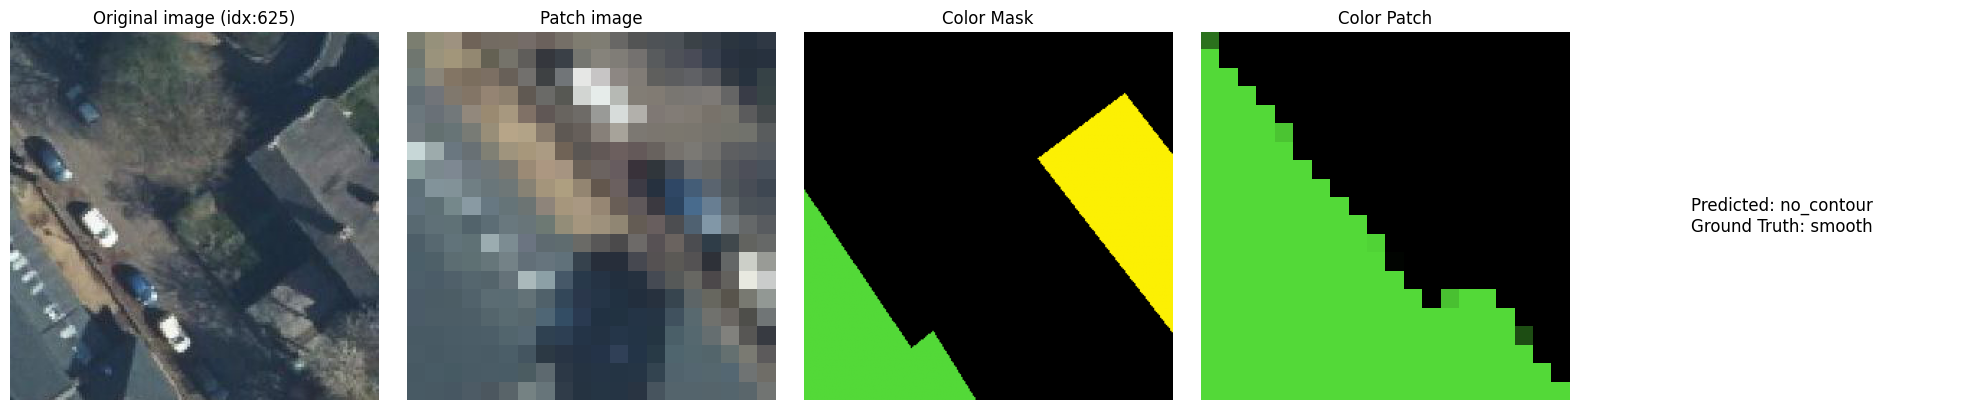

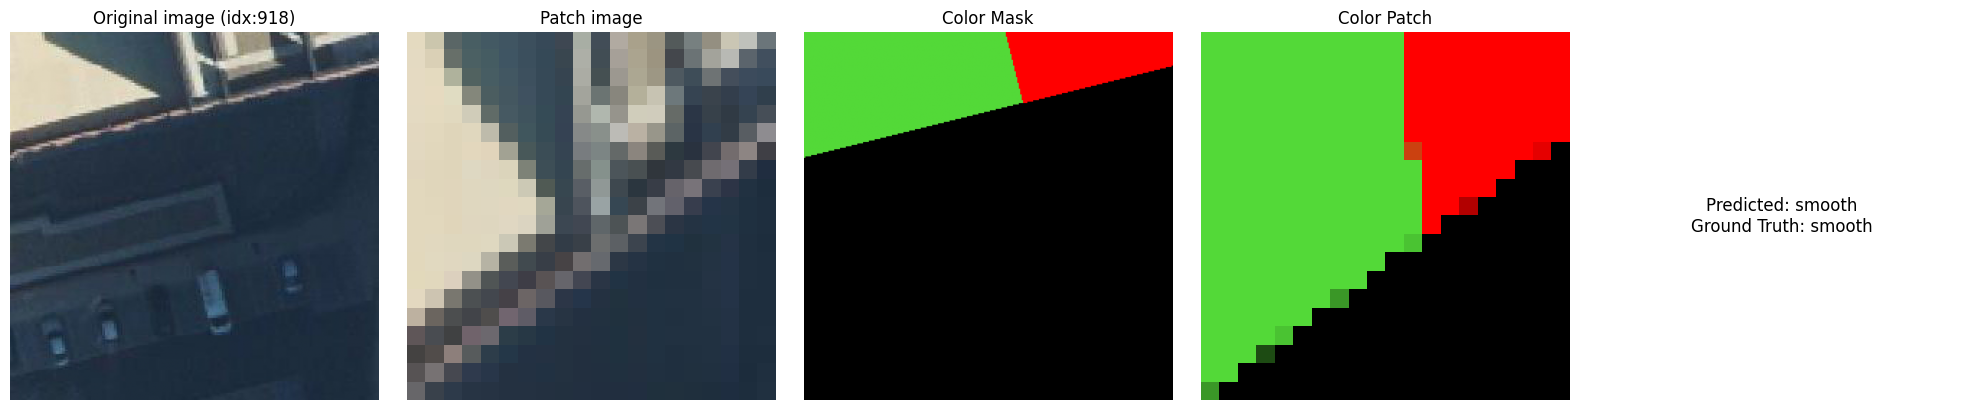

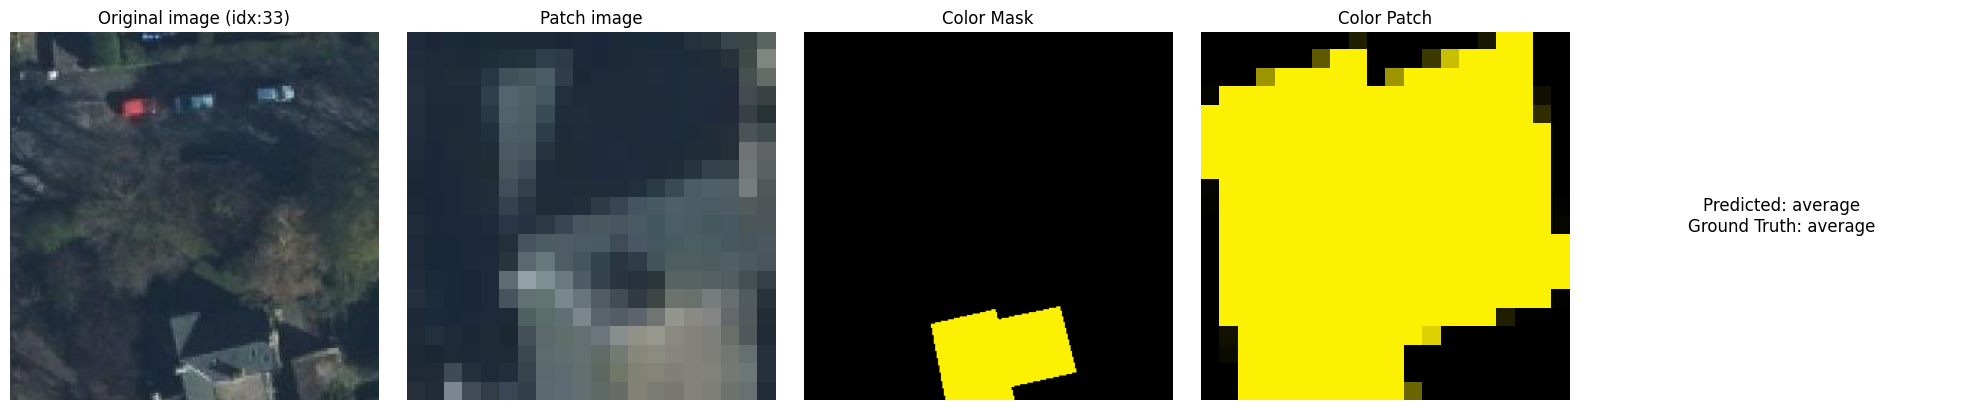

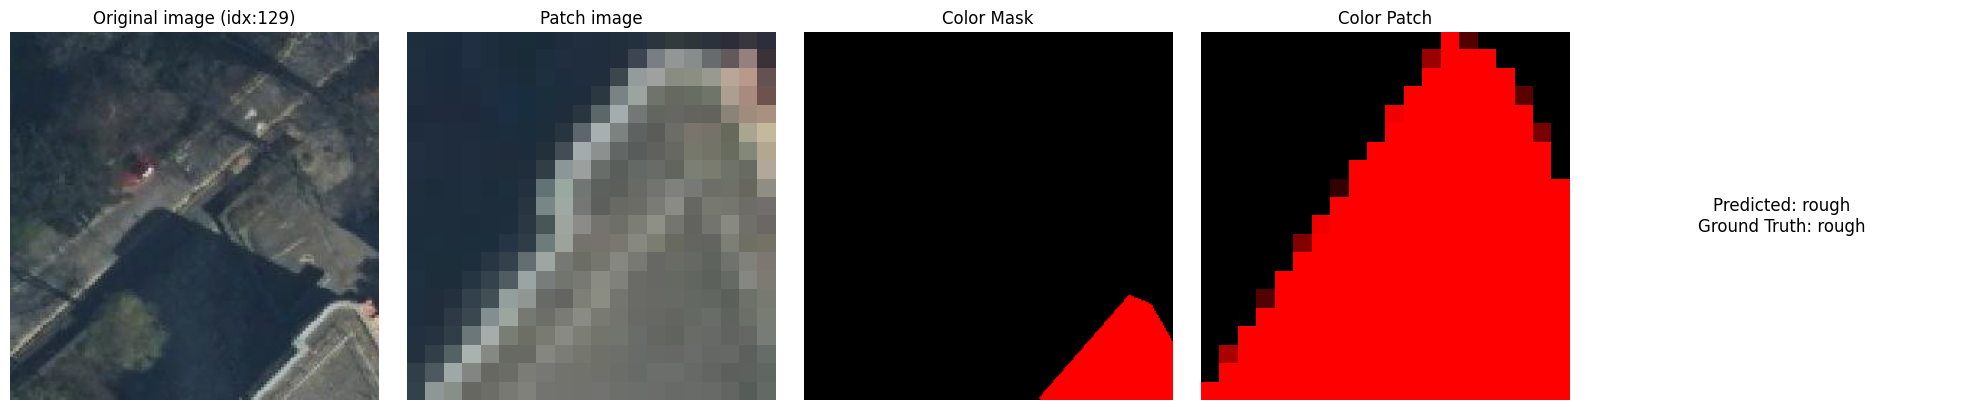

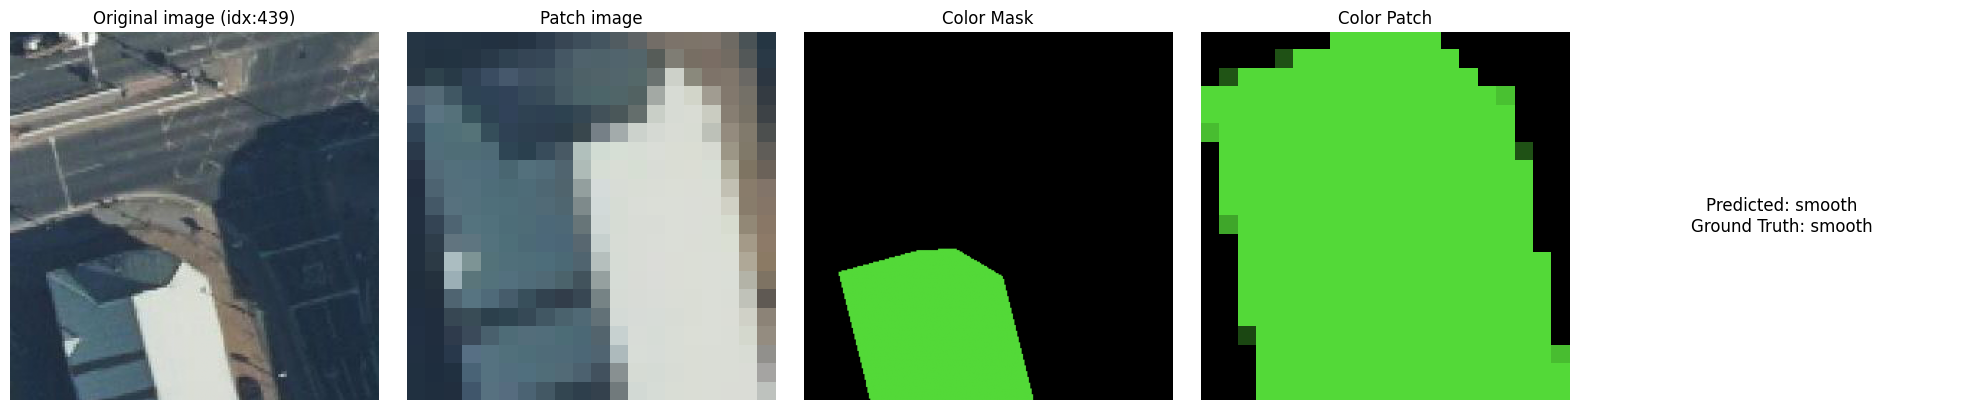

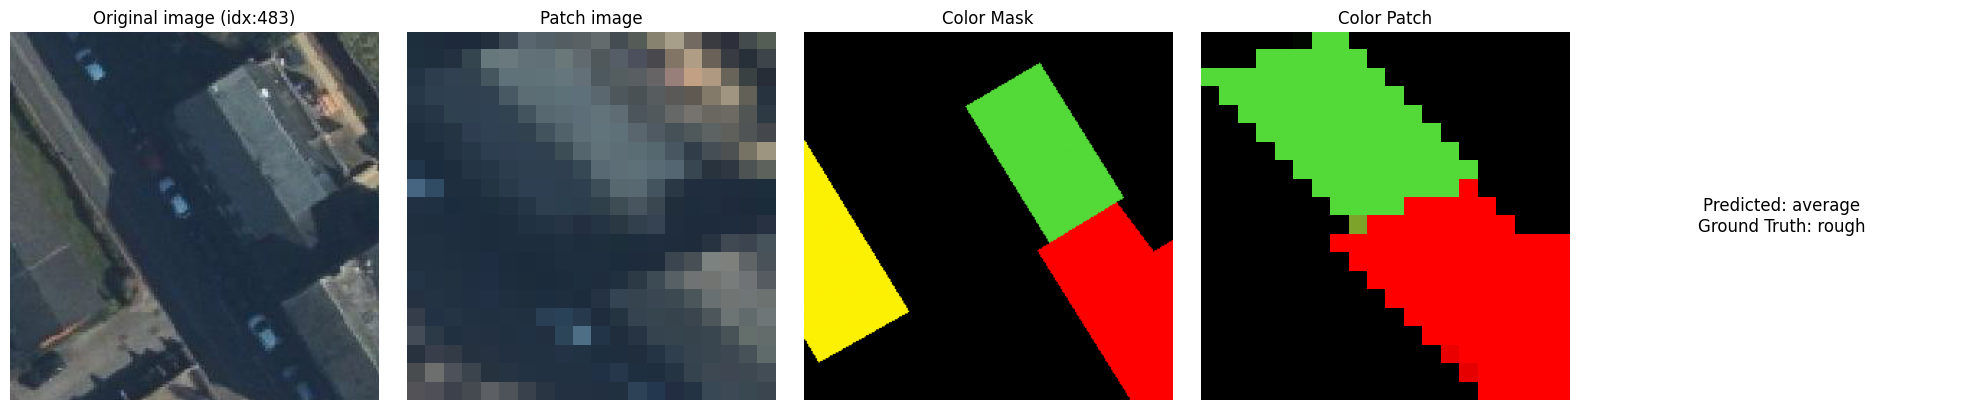

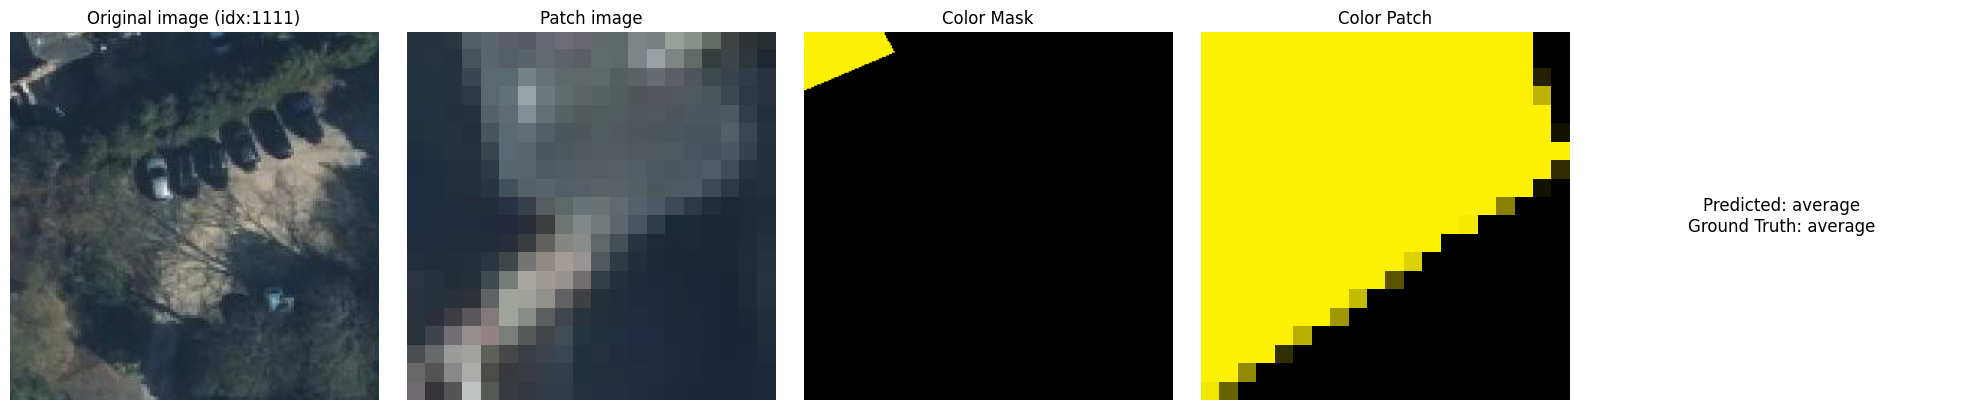

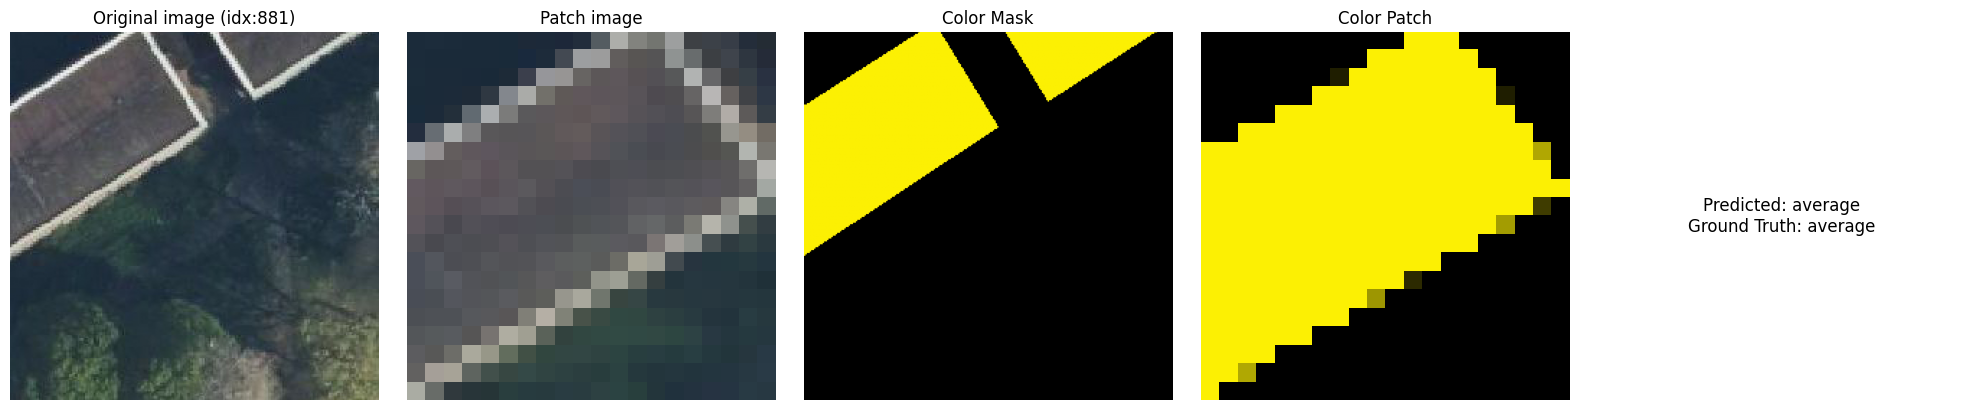

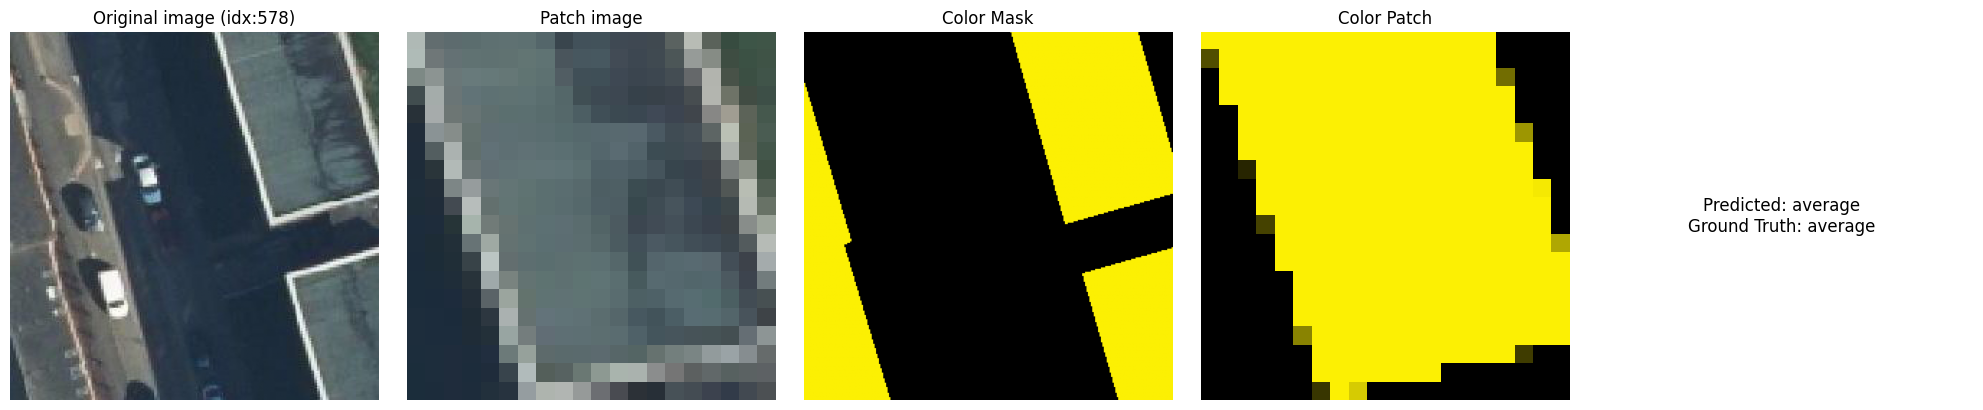

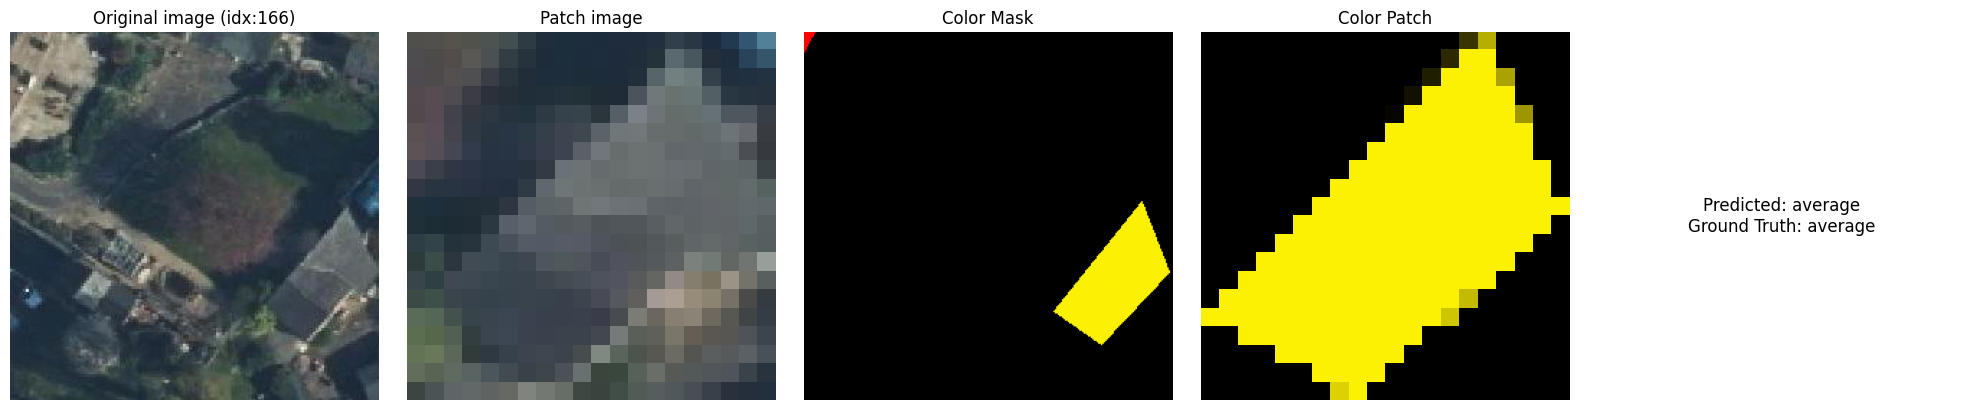

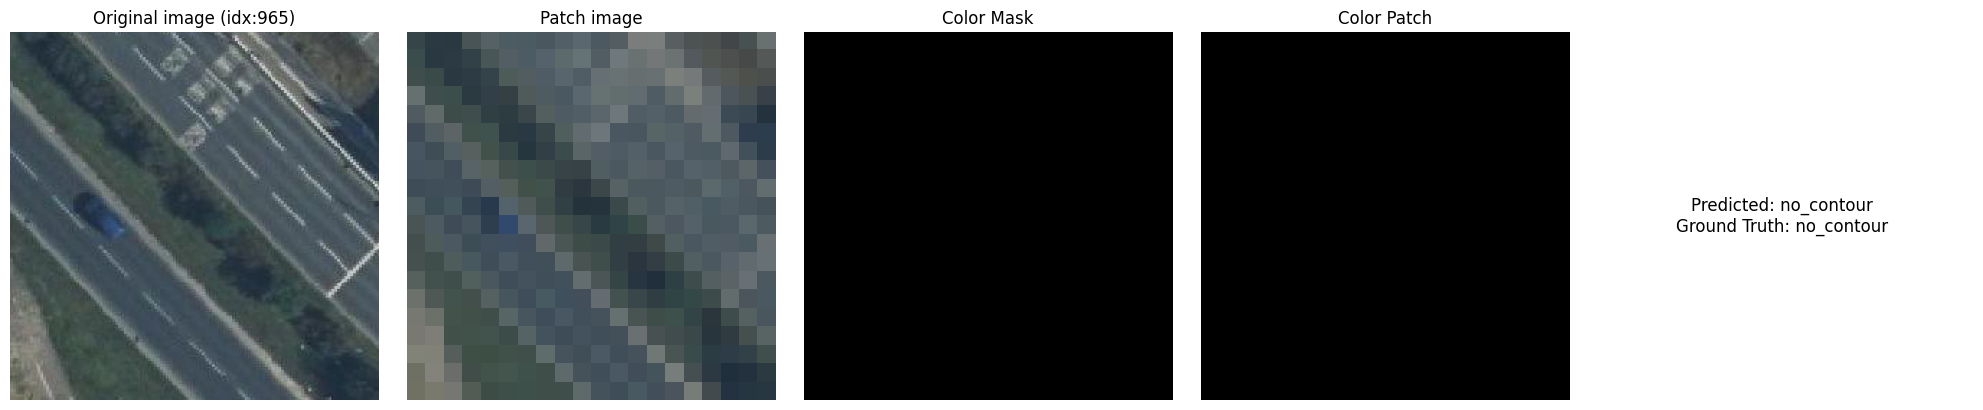

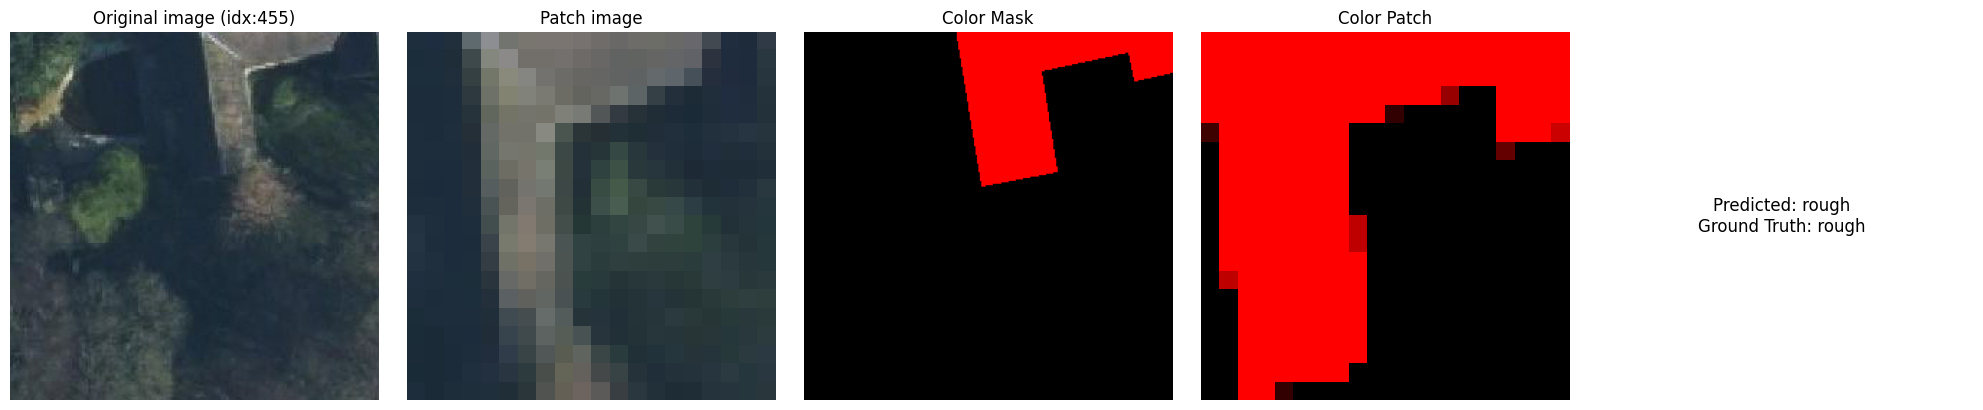

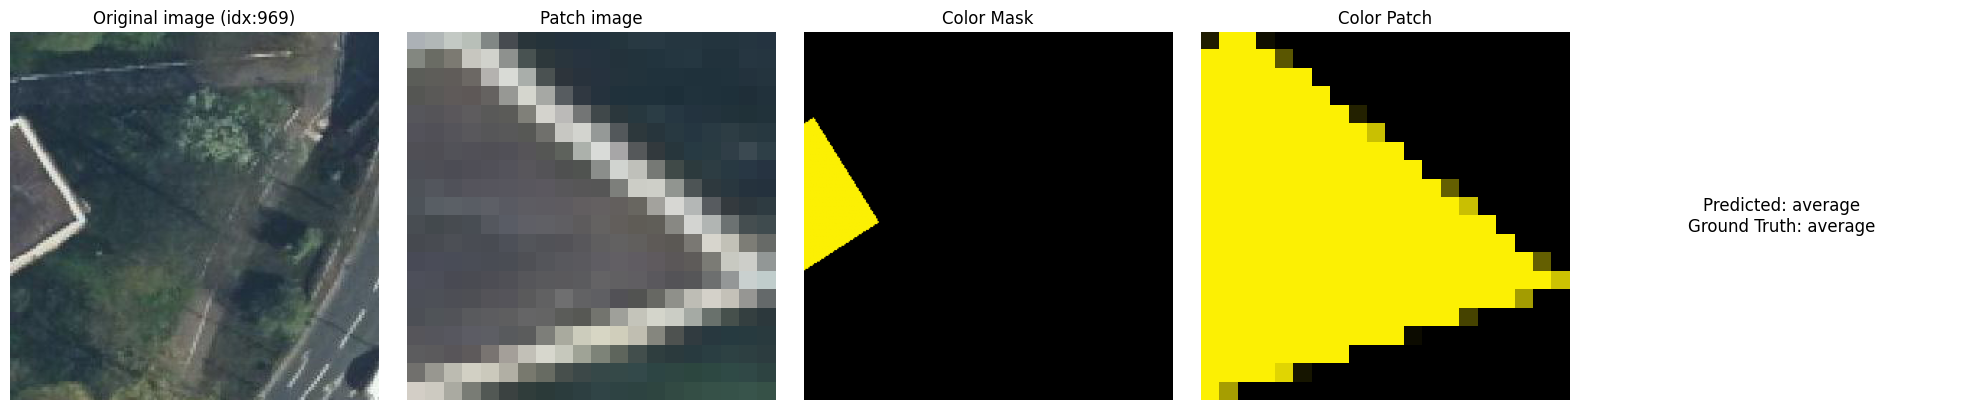

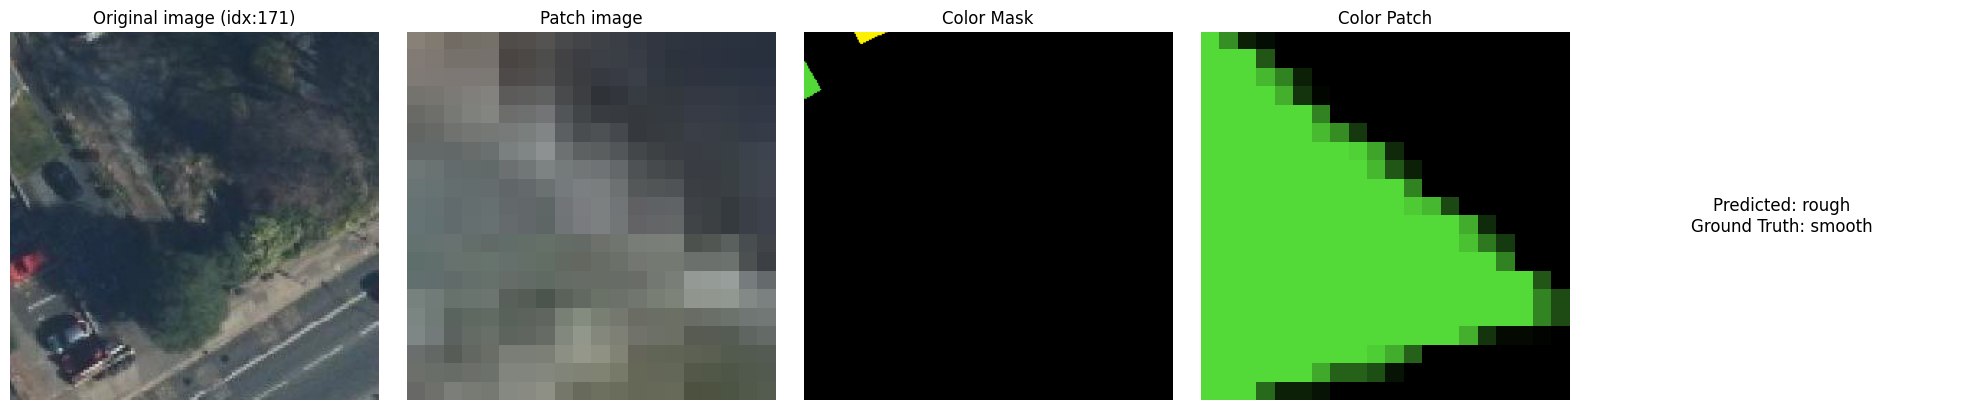

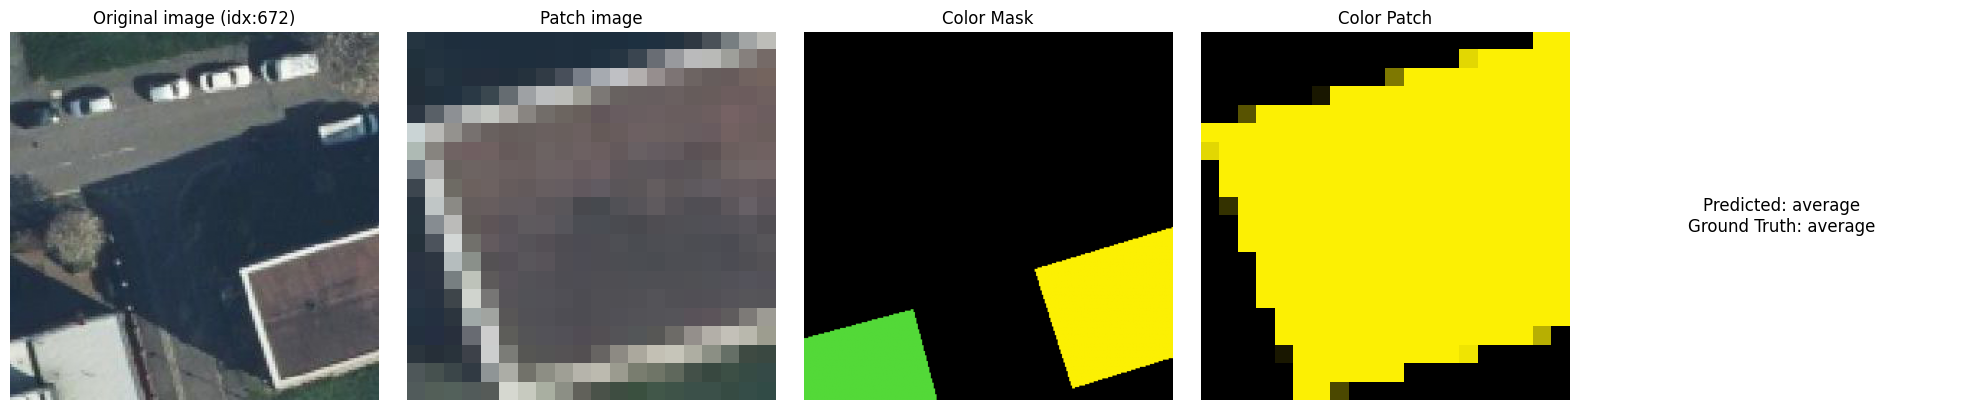

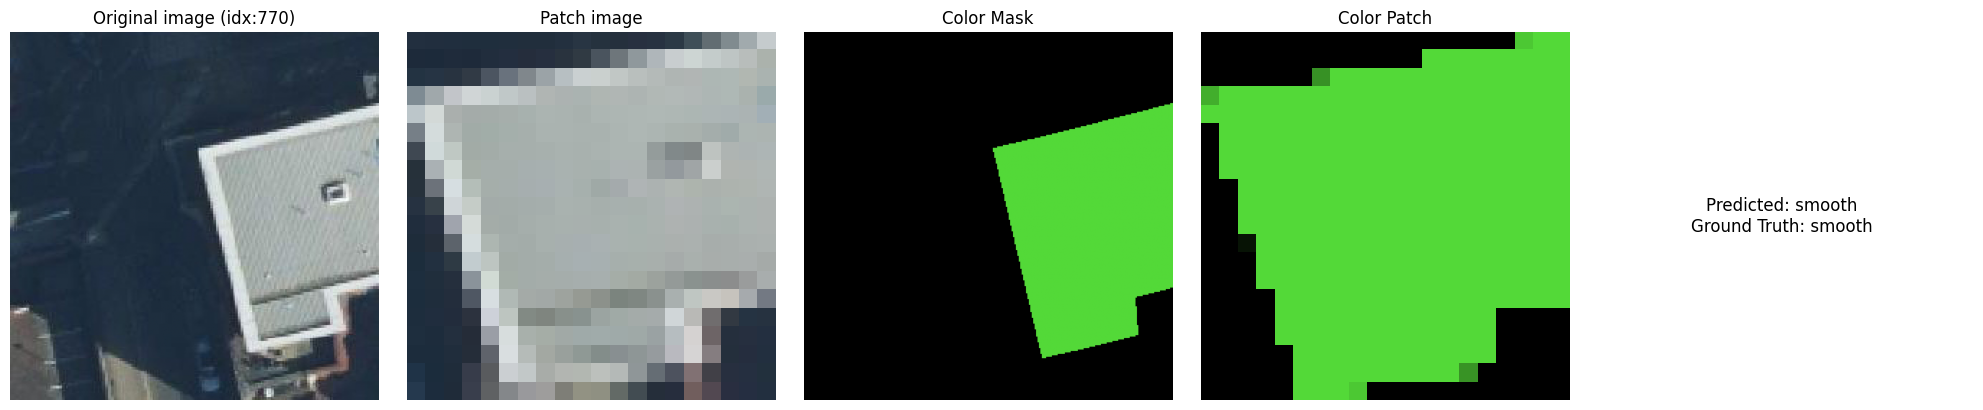

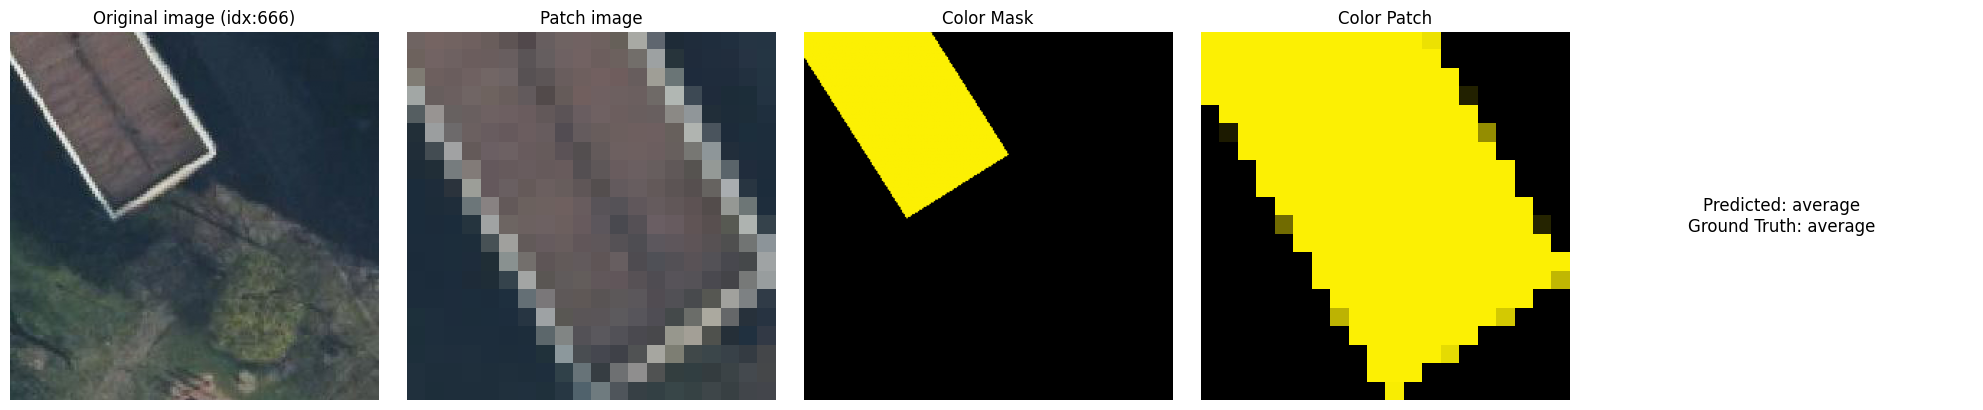

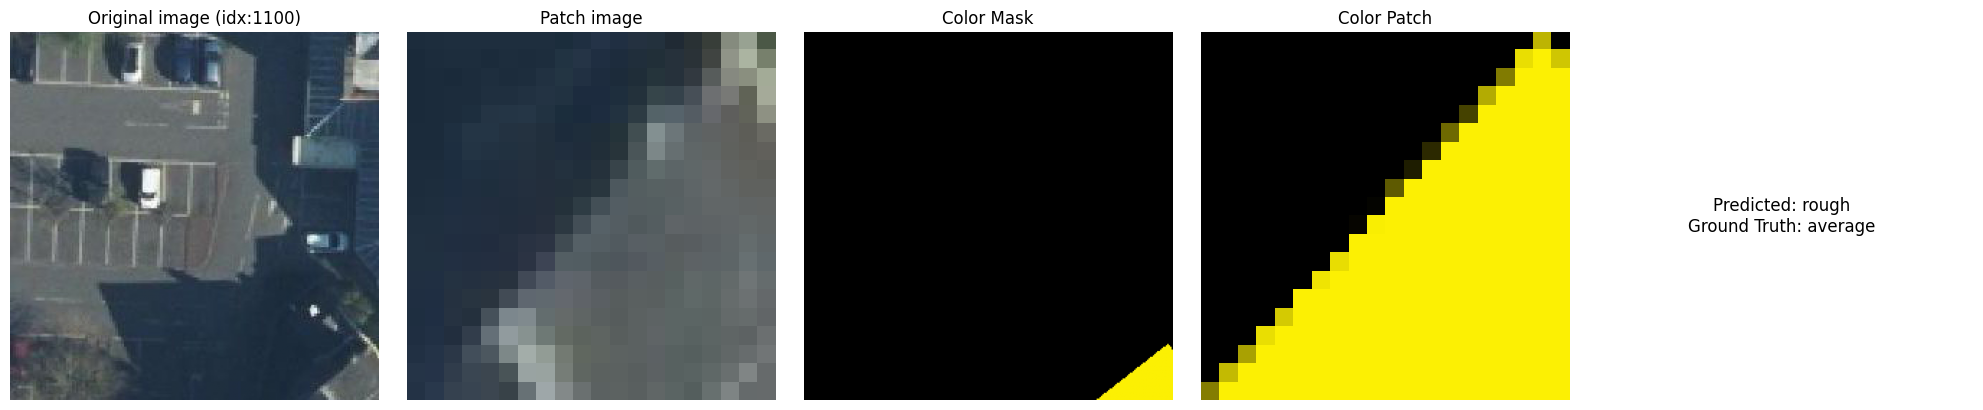

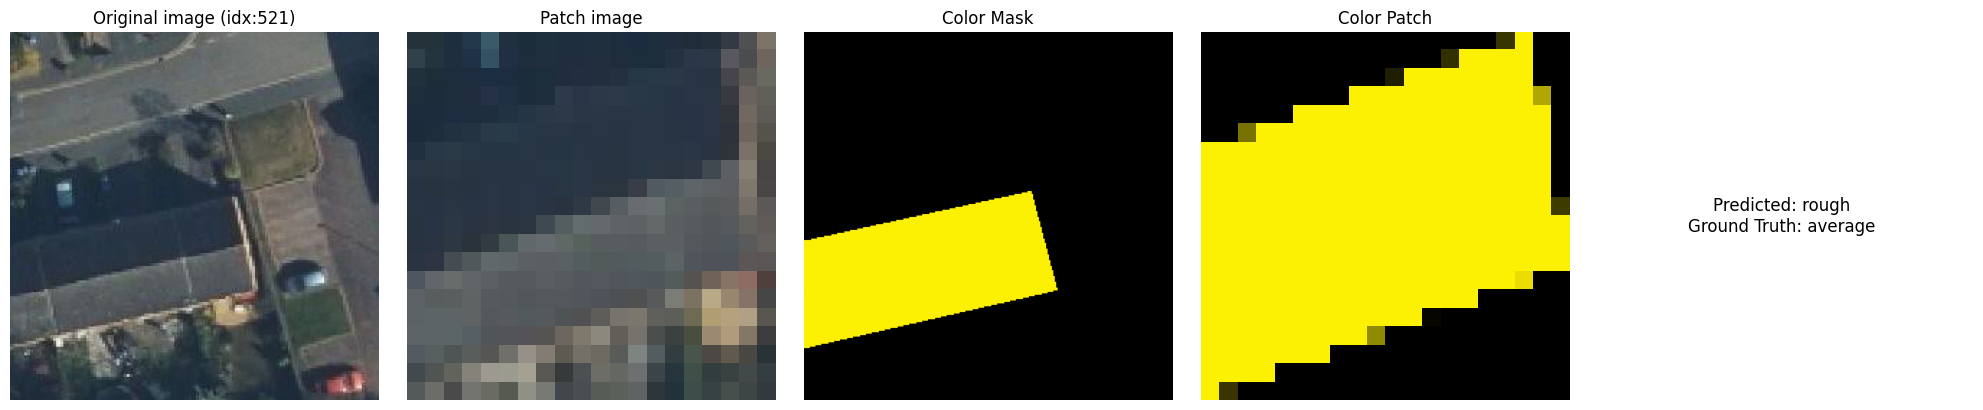

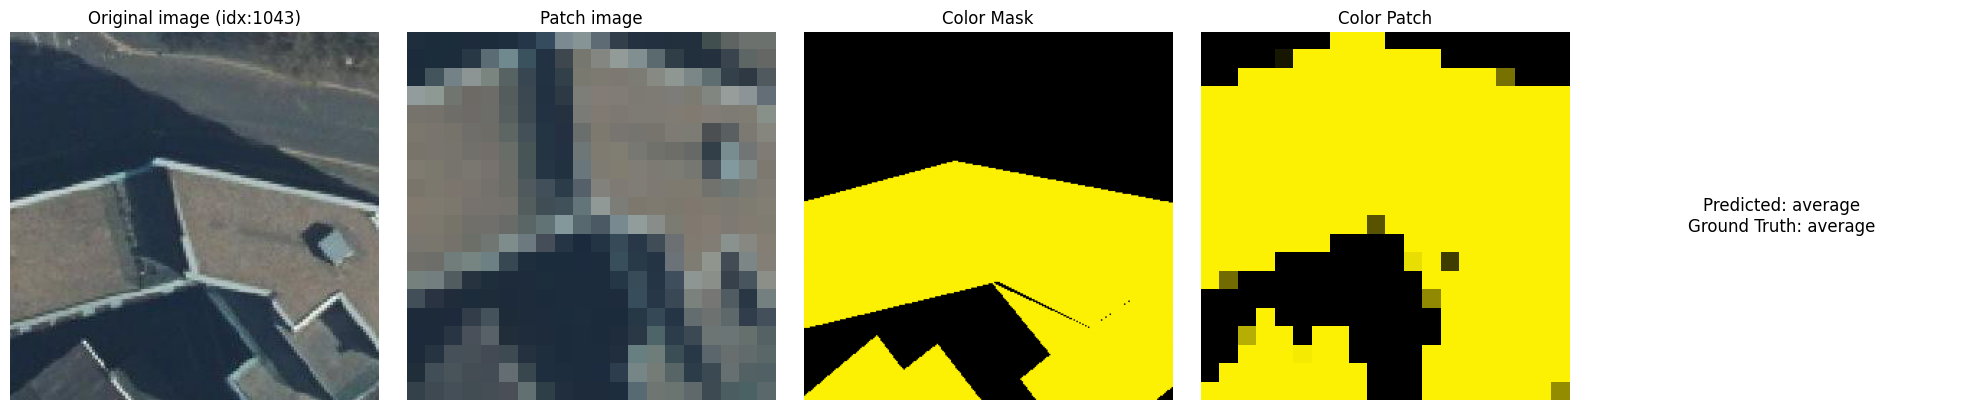

array([ 625,  918,   33,  129,  439,  483, 1111,  881,  578,  166,  965,
        455,  969,  171,  672,  770,  666, 1100,  521, 1043])

In [125]:
display_random_samples_with_predictions(model, images_, patches, color_masks_, label_map)


showing results...


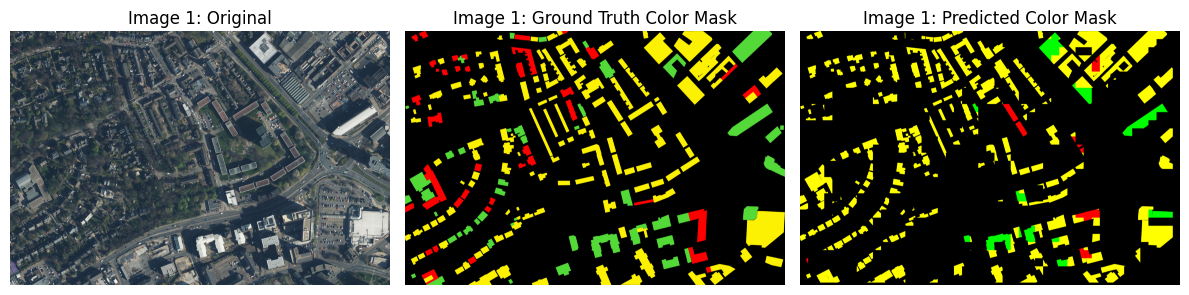

In [126]:
# Visualize results separately for each image
print("showing results...")
if not results:
    print("No images to display.")
else:
    for i, (original, pred,gt) in enumerate(results, 1):
        plt.figure(figsize=(12, 5))

            # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(original_image)
        plt.title(f"Image {i}: Original")
        plt.axis("off")

        # Ground Truth Color Mask
        plt.subplot(1, 3, 2)
        plt.imshow(full_mask_gt)
        plt.title(f"Image {i}: Ground Truth Color Mask")
        plt.axis("off")

        # Predicted Color Mask
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(full_mask_pred, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i}: Predicted Color Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
        plt.close()